# 02 · Análisis Exploratorio de Datos (EDA) — Titanic

**Objetivo (Fase 2):** comprender la naturaleza de los datos del Titanic, evaluar su calidad, descubrir patrones y plantear hipótesis verificables.

**Contenido**
1. Carga y diccionario de datos
2. Calidad: duplicados y variables redundantes
3. Valores faltantes
4. Valores atípicos (outliers)
5. Distribuciones y análisis univariado
6. Análisis bivariado y multivariado
7. Hipótesis y su verificación estadística
8. Insights principales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.precision", 3)
DATA = Path("../data"); FIG = Path("../figures"); FIG.mkdir(exist_ok=True)

def guardar(nombre):
    plt.tight_layout(); plt.savefig(FIG / nombre, dpi=120, bbox_inches="tight"); plt.show()

df = pd.read_csv(DATA / "titanic.csv")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


## 1. Diccionario de datos

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `survived` | Binaria (objetivo) | 1 = sobrevivió, 0 = no |
| `pclass` | Categórica ordinal | Clase del tiquete (1 = primera, 2 = segunda, 3 = tercera) |
| `sex` | Categórica nominal | Sexo del pasajero |
| `age` | Numérica continua | Edad en años |
| `sibsp` | Numérica discreta | N.º de hermanos/cónyuges a bordo |
| `parch` | Numérica discreta | N.º de padres/hijos a bordo |
| `fare` | Numérica continua | Tarifa pagada (libras esterlinas) |
| `embarked` | Categórica nominal | Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton) |
| `class` | Categórica | Igual a `pclass`, en texto |
| `who` | Categórica | man / woman / child |
| `adult_male` | Booleana | Hombre adulto |
| `deck` | Categórica | Cubierta del camarote (A–G) |
| `embark_town` | Categórica | Igual a `embarked`, en texto |
| `alive` | Categórica | Igual a `survived`, en texto (yes/no) |
| `alone` | Booleana | Viajaba sin familia |

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.384,0.487,0.00,0.000,0.000,1.0,1.000
pclass,891.0,2.309,0.836,1.00,2.000,3.000,3.0,3.000
age,714.0,29.699,14.526,0.42,20.125,28.000,38.0,80.000
sibsp,891.0,0.523,1.103,0.00,0.000,0.000,1.0,8.000
parch,891.0,0.382,0.806,0.00,0.000,0.000,0.0,6.000
fare,891.0,32.204,49.693,0.00,7.910,14.454,31.0,512.329


In [4]:
df.describe(include=["object", "bool"]).T

/tmp/ipykernel_596/3375859798.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object", "bool"]).T


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


## 2. Calidad: duplicados y variables redundantes

In [5]:
print("Filas duplicadas exactas:", df.duplicated().sum())

pares = [("survived", "alive"), ("pclass", "class"), ("embarked", "embark_town")]
for a, b in pares:
    print(f"{a} vs {b}: relación uno a uno →", (df.groupby(a)[b].nunique(dropna=True) <= 1).all())

print("¿alone == (sibsp + parch == 0)?", (df["alone"] == ((df.sibsp + df.parch) == 0)).all())
print("¿adult_male == (who == 'man')?", (df["adult_male"] == (df.who == "man")).all())

Filas duplicadas exactas: 107
survived vs alive: relación uno a uno → True
pclass vs class: relación uno a uno → True
embarked vs embark_town: relación uno a uno → True
¿alone == (sibsp + parch == 0)? True
¿adult_male == (who == 'man')? True


**Hallazgo de calidad:** hay **107 filas duplicadas**, pero **no son errores**: el dataset no incluye nombre ni número de tiquete, así que pasajeros distintos con el mismo perfil (por ejemplo, hombres de tercera clase sin edad registrada y misma tarifa) quedan idénticos. Por eso **se conservan**.

Además, varias columnas son **redundantes** (codifican la misma información): `alive` = `survived`, `class` = `pclass`, `embark_town` = `embarked`, `alone` se deriva de `sibsp + parch`, y `adult_male` se deriva de `who`. Para el análisis se trabaja con las variables originales; en el preprocesamiento se eliminarán las redundantes para evitar **fuga de información** (`alive`) y multicolinealidad.

## 3. Valores faltantes

In [6]:
faltantes = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
}).query("n_faltantes > 0").sort_values("porcentaje", ascending=False)
faltantes

,n_faltantes,porcentaje
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


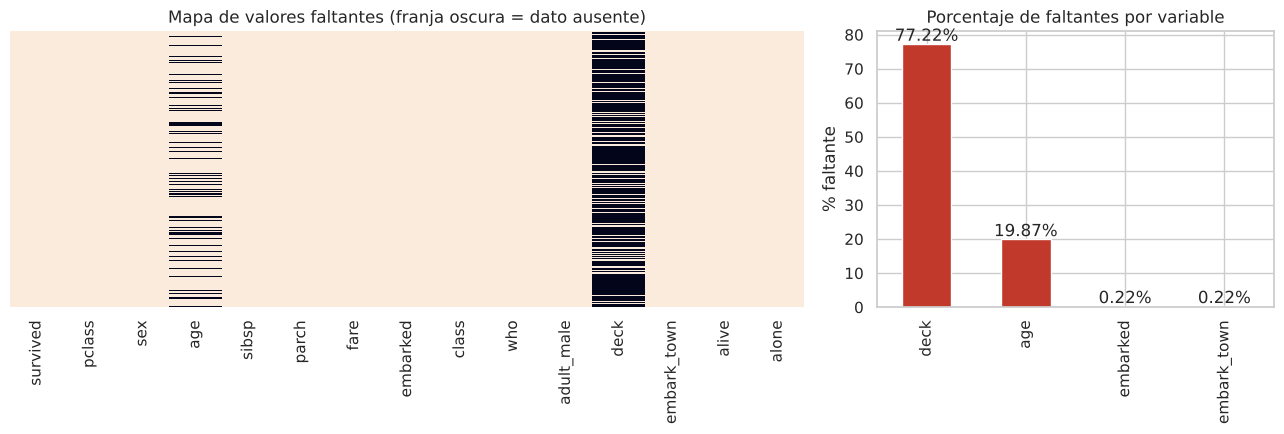

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1]})
sns.heatmap(df.isna(), cbar=False, cmap="rocket_r", yticklabels=False, ax=axes[0])
axes[0].set_title("Mapa de valores faltantes (franja oscura = dato ausente)")
faltantes["porcentaje"].plot(kind="bar", ax=axes[1], color="#c0392b")
axes[1].set_ylabel("% faltante"); axes[1].set_title("Porcentaje de faltantes por variable")
for i, v in enumerate(faltantes["porcentaje"]):
    axes[1].text(i, v + 1, f"{v}%", ha="center")
guardar("02_valores_faltantes.png")

### ¿Los faltantes son aleatorios?

Si la ausencia depende de otras variables, eliminar filas sesgaría el análisis. Se compara la tasa de faltantes de `age` y `deck` por clase y por supervivencia.

In [8]:
df["age_faltante"] = df["age"].isna()
df["deck_faltante"] = df["deck"].isna()
print("% de faltantes por clase:")
print((df.groupby("pclass")[["age_faltante", "deck_faltante"]].mean() * 100).round(1))
print("\nSupervivencia según si 'deck' está registrado:")
print(df.groupby("deck_faltante")["survived"].mean().round(3))
print("\nSupervivencia según si 'age' está registrada:")
print(df.groupby("age_faltante")["survived"].mean().round(3))

% de faltantes por clase:
        age_faltante  deck_faltante
pclass                             
1               13.9           19.0
2                6.0           91.3
3               27.7           97.6

Supervivencia según si 'deck' está registrado:
deck_faltante
False    0.670
True     0.299
Name: survived, dtype: float64

Supervivencia según si 'age' está registrada:
age_faltante
False    0.406
True     0.294
Name: survived, dtype: float64


**Interpretación y estrategia de tratamiento:**

| Variable | % faltante | Mecanismo | Estrategia propuesta |
|----------|-----------|-----------|----------------------|
| `deck` | ≈77 % | **No aleatorio**: falta casi siempre en 2.ª y 3.ª clase (los camarotes registrados eran sobre todo de 1.ª). Quienes tienen cubierta registrada sobrevivieron mucho más. | No se imputa (imputar 77 % sería inventar datos). Se elimina la columna y se crea un **indicador** `tiene_cubierta` (1/0), que conserva la señal. |
| `age` | ≈20 % | **Parcialmente dependiente** de la clase (falta más en 3.ª). | **Imputación por mediana agrupada** por `pclass` y `sex`, más un indicador `edad_faltante`. La mediana es robusta al sesgo. |
| `embarked` / `embark_town` | 0.2 % (2 filas) | Aleatorio, magnitud despreciable. | Imputar con la **moda** (`S`). |

Eliminar todas las filas con algún faltante dejaría solo ≈182 registros (80 % de pérdida), por eso se descarta esa opción.

In [9]:
print("Filas si se eliminara todo registro con algún faltante:", df.drop(columns=["age_faltante","deck_faltante"]).dropna().shape[0])

Filas si se eliminara todo registro con algún faltante: 182


## 4. Valores atípicos (outliers)

Se usan dos métodos estadísticos y un método gráfico:
- **IQR:** atípico si está por fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR].
- **Z-score:** atípico si |z| > 3.

In [10]:
numericas = ["age", "fare", "sibsp", "parch"]

def outliers_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < li) | (s > ls)).sum(), li, ls

filas = []
for c in numericas:
    s = df[c].dropna()
    n_iqr, li, ls = outliers_iqr(s)
    n_z = (np.abs(stats.zscore(s)) > 3).sum()
    filas.append([c, round(li, 2), round(ls, 2), n_iqr, round(n_iqr / len(s) * 100, 1), n_z, s.max()])
tabla_out = pd.DataFrame(filas, columns=["variable", "límite_inf_IQR", "límite_sup_IQR",
                                         "outliers_IQR", "%_IQR", "outliers_z>3", "máximo"])
tabla_out

,variable,límite_inf_IQR,límite_sup_IQR,outliers_IQR,%_IQR,outliers_z>3,máximo
0,age,-6.69,64.81,11,1.5,2,80.000
1,fare,-26.72,65.63,116,13.0,20,512.329
2,sibsp,-1.50,2.50,46,5.2,30,8.000
3,parch,0.00,0.00,213,23.9,15,6.000


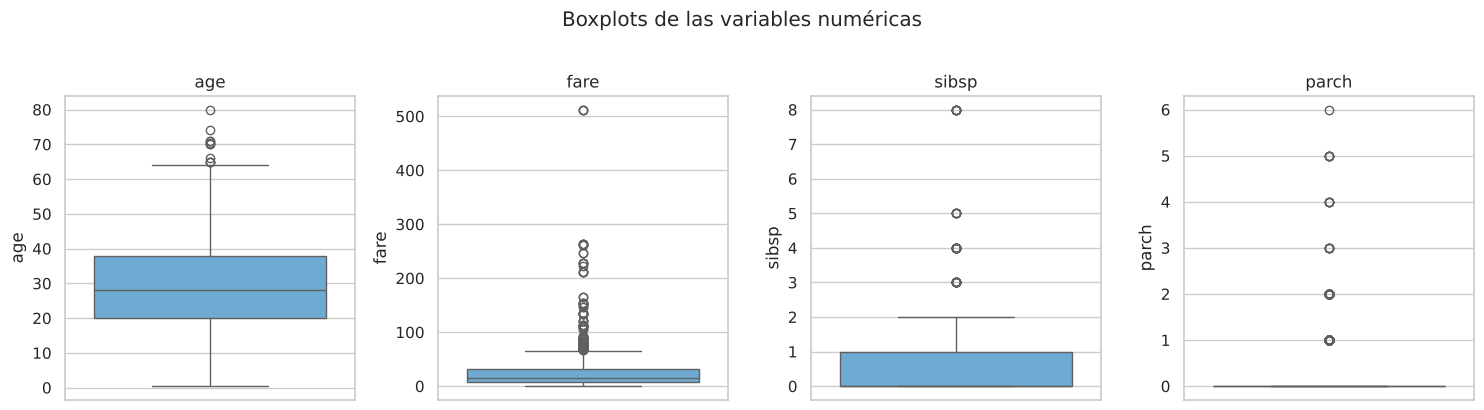

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, c in zip(axes, numericas):
    sns.boxplot(y=df[c], ax=ax, color="#5DADE2")
    ax.set_title(c)
plt.suptitle("Boxplots de las variables numéricas", y=1.02)
guardar("02_boxplots_outliers.png")

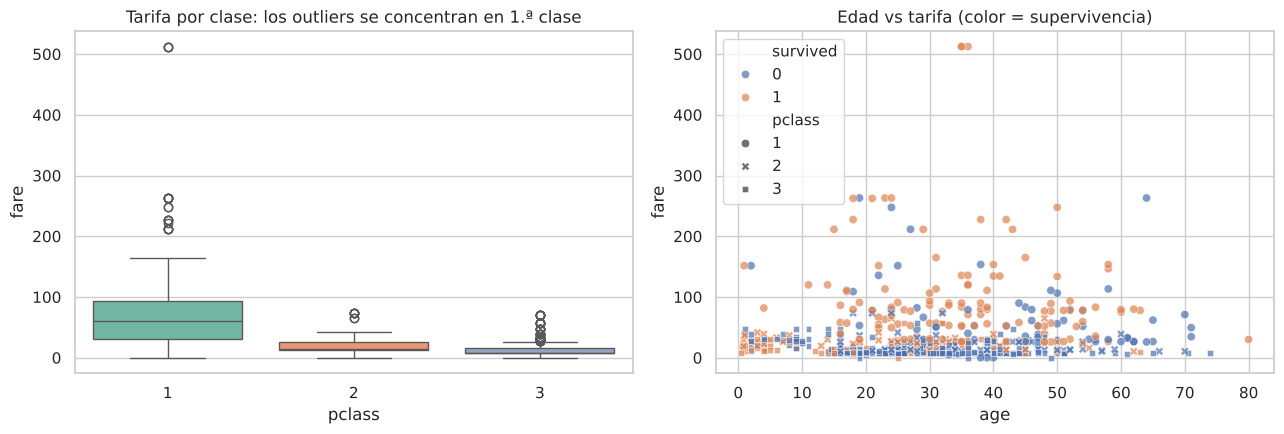

     pclass     sex   age     fare  survived
737       1    male  35.0  512.329         1
679       1    male  36.0  512.329         1
258       1  female  35.0  512.329         1
438       1    male  64.0  263.000         0
88        1  female  23.0  263.000         1
27        1    male  19.0  263.000         0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[0], palette="Set2", hue="pclass", legend=False)
axes[0].set_title("Tarifa por clase: los outliers se concentran en 1.ª clase")
sns.scatterplot(data=df, x="age", y="fare", hue="survived", style="pclass", ax=axes[1], alpha=0.7)
axes[1].set_title("Edad vs tarifa (color = supervivencia)")
guardar("02_outliers_fare_por_clase.png")
print(df.sort_values("fare", ascending=False)[["pclass", "sex", "age", "fare", "survived"]].head(6))

**Discusión: ¿conservar o ajustar?**

- **`fare`:** es la variable con más atípicos (más de 100 según IQR). Sin embargo, el boxplot por clase muestra que **son tarifas reales de primera clase** (camarotes de lujo, tiquetes grupales), no errores de digitación. El valor máximo (512.33) lo comparten varios pasajeros del mismo tiquete. **Decisión: conservarlos** y aplicar una **transformación logarítmica** (`log1p`) para reducir su influencia. También hay 15 tarifas en 0 (posiblemente tripulación o invitados), que se conservan.
- **`age`:** los pocos atípicos (> 64 años) son edades plausibles. **Se conservan.**
- **`sibsp` y `parch`:** sus atípicos son familias numerosas (por ejemplo, 8 hermanos). Son reales e informativos (las familias grandes sobrevivieron menos). **Se conservan**, y se resumirán en una nueva variable `tamano_familia`.

Conclusión: en este dataset los outliers son **información legítima**; eliminarlos borraría precisamente a los pasajeros más ricos y a las familias grandes.

## 5. Distribuciones y análisis univariado

### 5.1 Variables numéricas

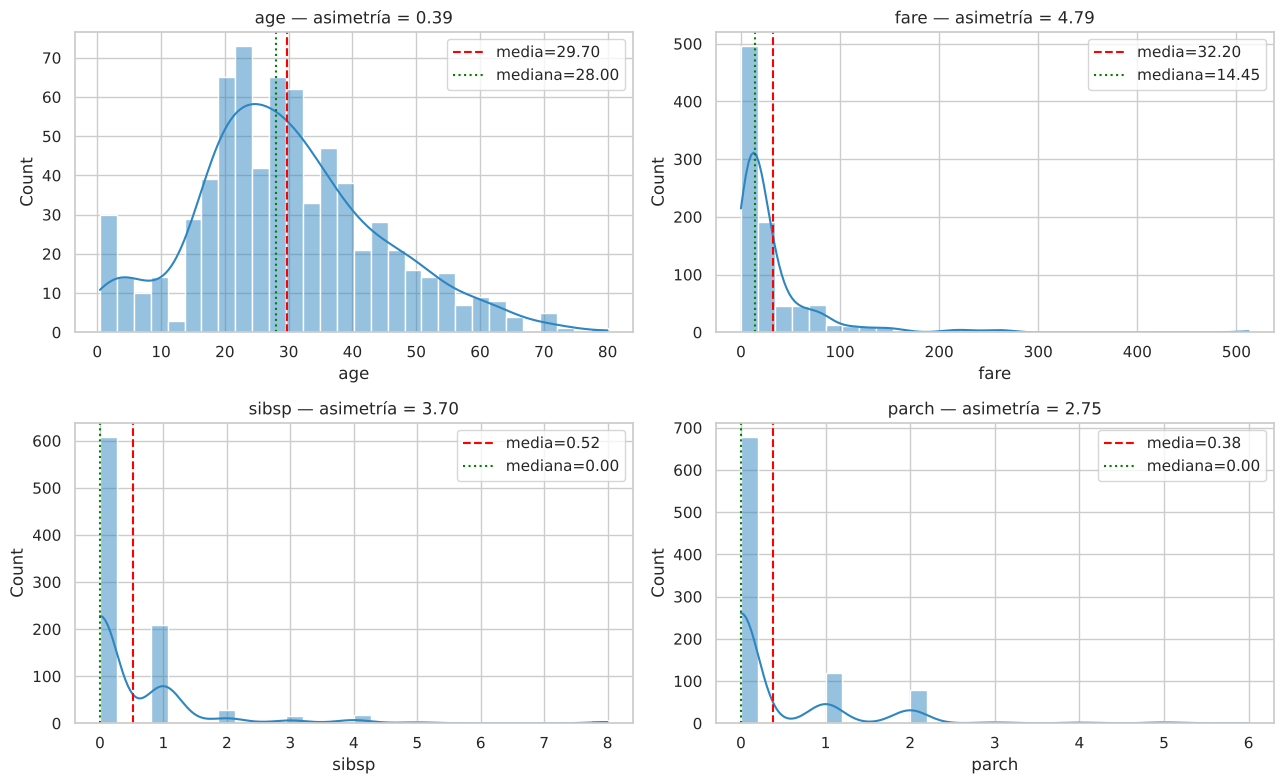

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.ravel(), numericas):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#2E86C1", bins=30)
    ax.axvline(df[c].mean(), color="red", ls="--", label=f"media={df[c].mean():.2f}")
    ax.axvline(df[c].median(), color="green", ls=":", label=f"mediana={df[c].median():.2f}")
    ax.set_title(f"{c} — asimetría = {df[c].skew():.2f}"); ax.legend()
guardar("02_histogramas_numericas.png")

In [14]:
forma = pd.DataFrame({
    "media": df[numericas].mean(), "mediana": df[numericas].median(),
    "desv_std": df[numericas].std(), "asimetría": df[numericas].skew(),
    "curtosis": df[numericas].kurt(),
})
forma["p_valor_normalidad"] = [stats.normaltest(df[c].dropna()).pvalue for c in numericas]
forma.round(3)

,media,mediana,desv_std,asimetría,curtosis,p_valor_normalidad
age,29.699,28.000,14.526,0.389,0.178,0.0
fare,32.204,14.454,49.693,4.787,33.398,0.0
sibsp,0.523,0.000,1.103,3.695,17.880,0.0
parch,0.382,0.000,0.806,2.749,9.778,0.0


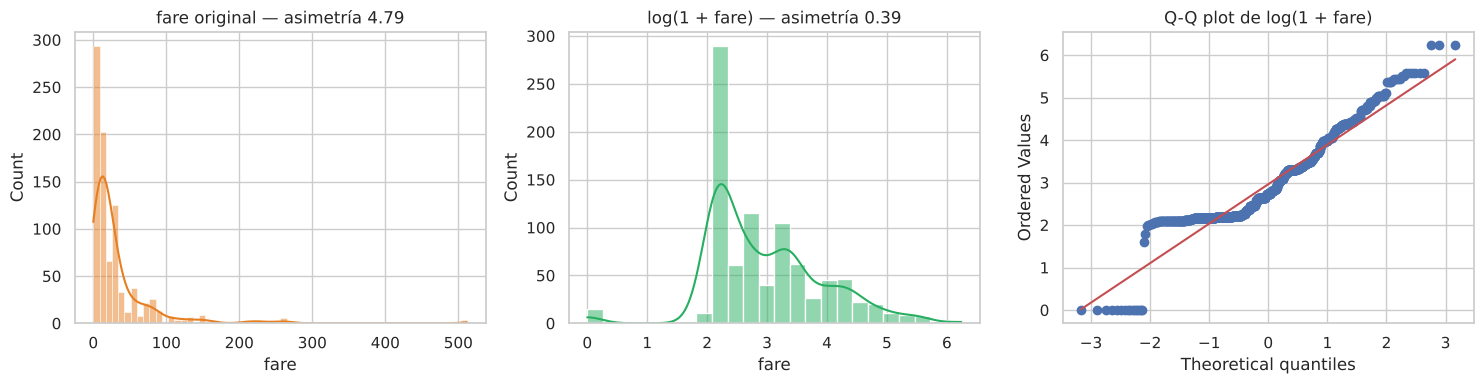

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["fare"], kde=True, ax=axes[0], color="#E67E22")
axes[0].set_title(f"fare original — asimetría {df.fare.skew():.2f}")
sns.histplot(np.log1p(df["fare"]), kde=True, ax=axes[1], color="#27AE60")
axes[1].set_title(f"log(1 + fare) — asimetría {np.log1p(df.fare).skew():.2f}")
stats.probplot(np.log1p(df["fare"]), plot=axes[2]); axes[2].set_title("Q-Q plot de log(1 + fare)")
guardar("02_transformacion_log_fare.png")

**Interpretación:**
- **`age`:** casi simétrica (asimetría ≈ 0.39), ligeramente sesgada a la derecha, con un pequeño pico de niños menores de 5 años. Media y mediana son cercanas (≈ 29.7 vs 28). Solo requiere **estandarización**.
- **`fare`:** **muy sesgada a la derecha** (asimetría ≈ 4.8, curtosis ≈ 33). La media (≈ 32) es más del doble de la mediana (≈ 14.5). La transformación `log1p` reduce la asimetría a ≈ 0.4, por lo que **se aplicará en el preprocesamiento**.
- **`sibsp` y `parch`:** discretas y concentradas en 0 (la mayoría viajaba sin esos familiares).
- Ninguna variable es normal (p-valor < 0.05 en la prueba de D'Agostino), lo que justifica usar **medianas** para imputar y **pruebas no paramétricas** para comparar grupos.

### 5.2 Variables categóricas

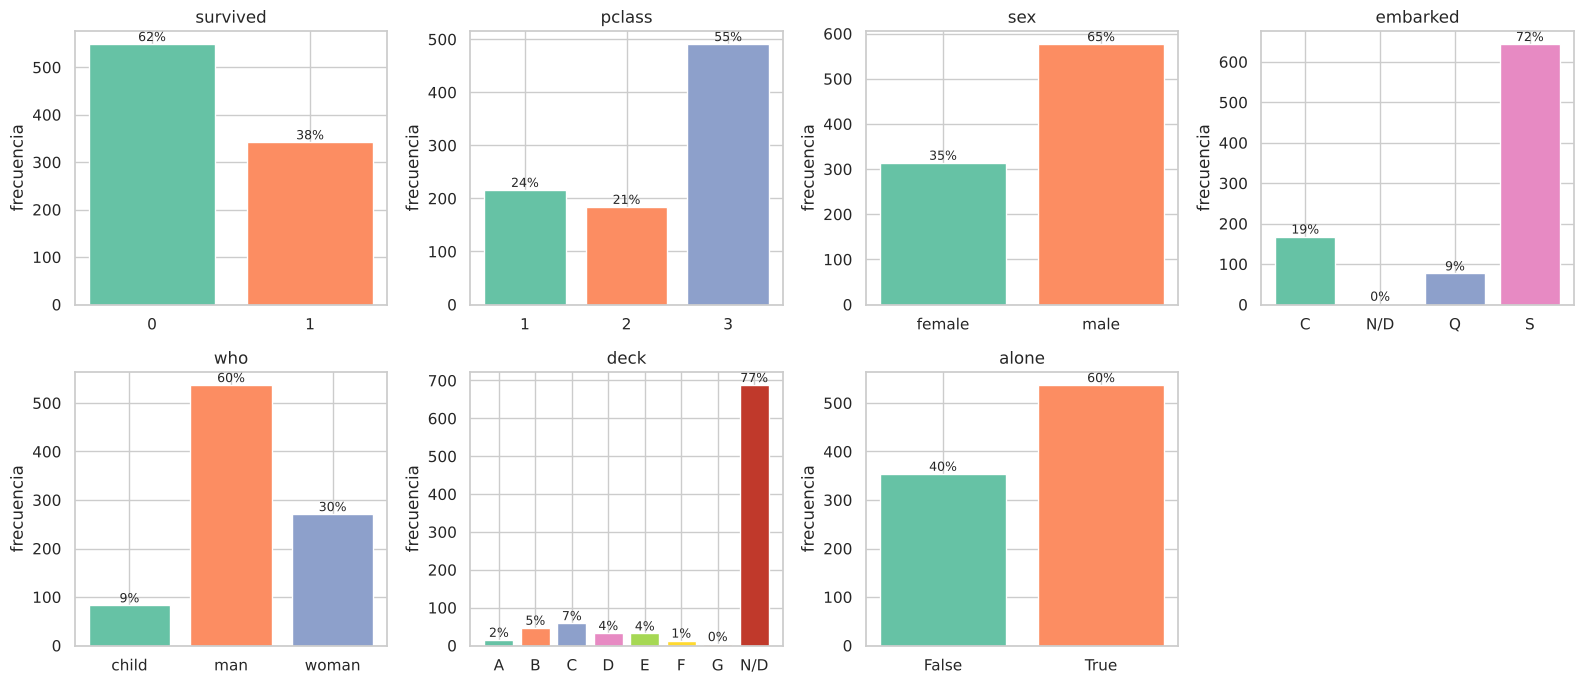

In [16]:
categoricas = ["survived", "pclass", "sex", "embarked", "who", "deck", "alone"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), categoricas):
    conteo = df[c].astype(object).fillna("N/D").astype(str).value_counts().sort_index()
    colores = ["#c0392b" if k == "N/D" else sns.color_palette("Set2")[i % 8] for i, k in enumerate(conteo.index)]
    ax.bar(conteo.index, conteo.values, color=colores)
    for i, v in enumerate(conteo.values):
        ax.text(i, v, f"{v/len(df)*100:.0f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title(c); ax.set_ylabel("frecuencia")
axes.ravel()[-1].axis("off")
guardar("02_barras_categoricas.png")

In [17]:
for c in ["survived", "pclass", "sex", "embarked"]:
    print(f"--- {c} ---")
    print(df[c].value_counts(normalize=True).mul(100).round(1).to_string(), "\n")

--- survived ---
survived
0    61.6
1    38.4 

--- pclass ---
pclass
3    55.1
1    24.2
2    20.7 

--- sex ---
sex
male      64.8
female    35.2 

--- embarked ---
embarked
S    72.4
C    18.9
Q     8.7 



**Interpretación:**
- **Clase objetivo desbalanceada:** solo ≈ 38 % sobrevivió (342 de 891). Este desbalance moderado debe tenerse en cuenta al modelar (por ejemplo, usar métricas como F1 o validación estratificada).
- **Predominio de 3.ª clase** (≈ 55 %) y de **hombres** (≈ 65 %).
- **Southampton** fue el puerto de la gran mayoría (≈ 72 %).
- En `deck`, la categoría más frecuente es "NaN", lo que confirma que no conviene usarla directamente.

## 6. Análisis bivariado y multivariado

### 6.1 Supervivencia frente a variables categóricas (tablas cruzadas)

In [18]:
for c in ["sex", "pclass", "embarked", "who"]:
    print(f"\n=== Tasa de supervivencia por {c} ===")
    print(pd.crosstab(df[c], df["survived"], margins=True, normalize="index").round(3))


=== Tasa de supervivencia por sex ===
survived      0      1
sex                   
female    0.258  0.742
male      0.811  0.189
All       0.616  0.384

=== Tasa de supervivencia por pclass ===
survived      0      1
pclass                
1         0.370  0.630
2         0.527  0.473
3         0.758  0.242
All       0.616  0.384

=== Tasa de supervivencia por embarked ===
survived      0      1
embarked              
C         0.446  0.554
Q         0.610  0.390
S         0.663  0.337
All       0.618  0.382

=== Tasa de supervivencia por who ===
survived      0      1
who                   
child     0.410  0.590
man       0.836  0.164
woman     0.244  0.756
All       0.616  0.384


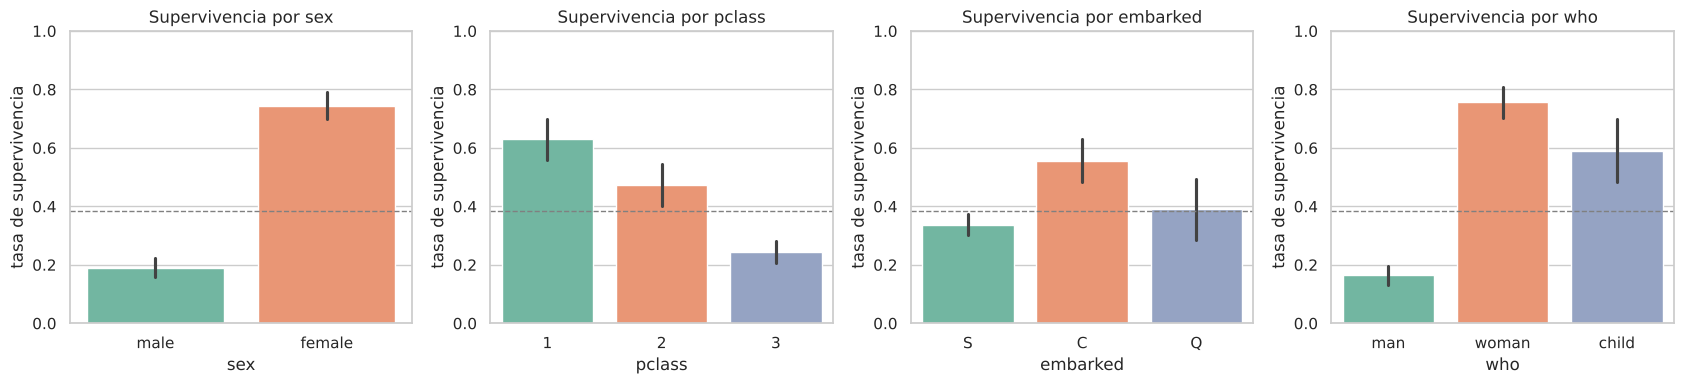

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, c in zip(axes, ["sex", "pclass", "embarked", "who"]):
    sns.barplot(data=df, x=c, y="survived", ax=ax, hue=c, legend=False, palette="Set2", errorbar=("ci", 95))
    ax.set_ylim(0, 1); ax.set_ylabel("tasa de supervivencia"); ax.set_title(f"Supervivencia por {c}")
    ax.axhline(df.survived.mean(), color="gray", ls="--", lw=1)
guardar("02_supervivencia_por_categoricas.png")

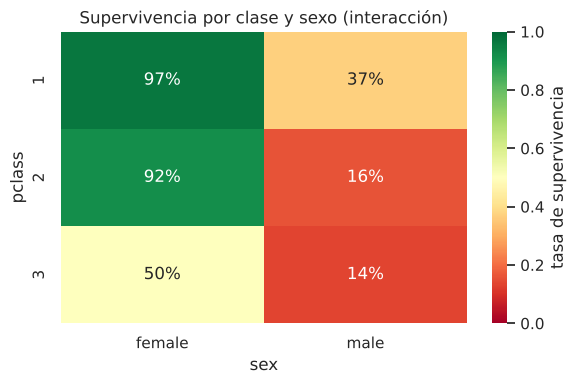

sex,female,male
pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


In [20]:
tabla = pd.crosstab([df["pclass"], df["sex"]], df["survived"], normalize="index")[1].unstack()
plt.figure(figsize=(6, 4))
sns.heatmap(tabla, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={"label": "tasa de supervivencia"})
plt.title("Supervivencia por clase y sexo (interacción)")
guardar("02_heatmap_clase_sexo.png")
tabla.round(3)

**Interpretación:** el sexo y la clase son los factores más fuertes. Las **mujeres de 1.ª y 2.ª clase sobrevivieron más del 90 %**, mientras que los **hombres de 2.ª y 3.ª clase sobrevivieron menos del 16 %**. Además hay **interacción**: el efecto de la clase es mucho mayor en las mujeres (de ≈ 97 % a ≈ 50 %) que en los hombres. El puerto de Cherbourg muestra mayor supervivencia, pero probablemente porque allí embarcaron más pasajeros de 1.ª clase (se verifica abajo).

In [21]:
print("Composición de clase por puerto de embarque (%):")
pd.crosstab(df["embarked"], df["pclass"], normalize="index").mul(100).round(1)

Composición de clase por puerto de embarque (%):


pclass,1,2,3
embarked,,,
C,50.6,10.1,39.3
Q,2.6,3.9,93.5
S,19.7,25.5,54.8


### 6.2 Supervivencia frente a variables numéricas

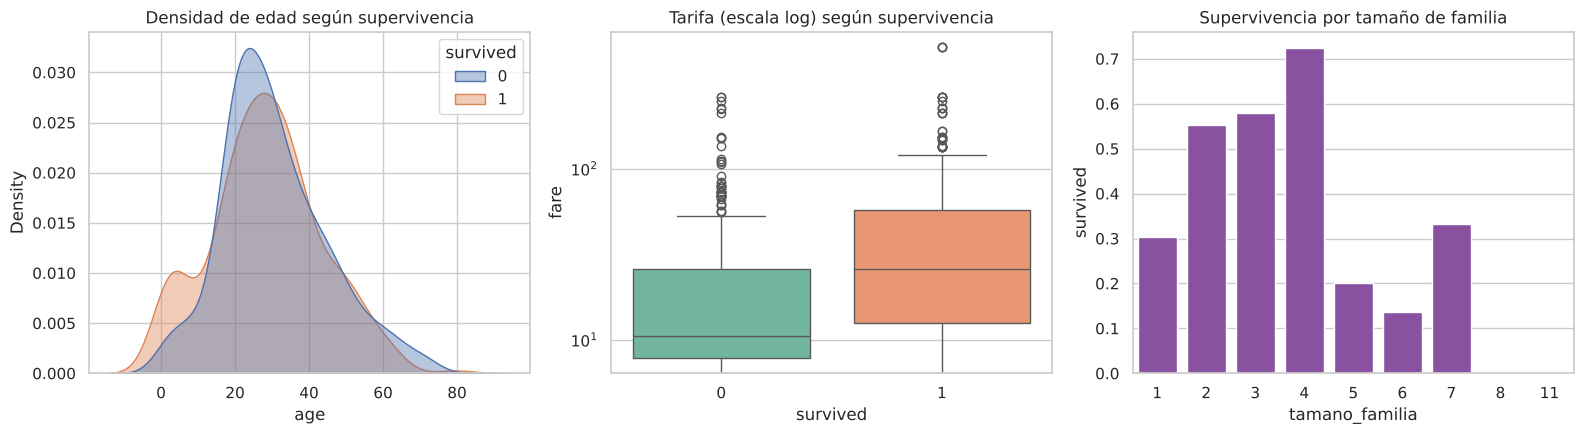

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.kdeplot(data=df, x="age", hue="survived", fill=True, common_norm=False, ax=axes[0], alpha=0.4)
axes[0].set_title("Densidad de edad según supervivencia")
sns.boxplot(data=df, x="survived", y="fare", ax=axes[1], hue="survived", legend=False, palette="Set2")
axes[1].set_yscale("log"); axes[1].set_title("Tarifa (escala log) según supervivencia")
df["tamano_familia"] = df["sibsp"] + df["parch"] + 1
sns.barplot(data=df, x="tamano_familia", y="survived", ax=axes[2], color="#8E44AD", errorbar=None)
axes[2].set_title("Supervivencia por tamaño de familia")
guardar("02_supervivencia_por_numericas.png")

In [23]:
df["grupo_edad"] = pd.cut(df["age"], bins=[0, 12, 18, 30, 45, 60, 80],
                          labels=["0-12", "13-18", "19-30", "31-45", "46-60", "61-80"])
pd.crosstab(df["grupo_edad"], df["survived"], normalize="index", margins=True).round(3)

survived,0,1
grupo_edad,,
0-12,0.420,0.580
13-18,0.571,0.429
19-30,0.644,0.356
31-45,0.574,0.426
46-60,0.593,0.407
61-80,0.773,0.227
All,0.594,0.406


**Interpretación:**
- Los **niños menores de 12 años** tuvieron una supervivencia notablemente mayor (≈ 58 %); en los adultos la edad tiene poco efecto aislado.
- Los sobrevivientes pagaron **tarifas mayores** (mediana ≈ 26 vs ≈ 10), lo que refleja el efecto de la clase.
- La relación con el tamaño de familia es **no lineal**: viajar solo (≈ 30 %) o en familias grandes (5 o más, ≈ 16 % en conjunto) reduce la supervivencia; las familias de 2 a 4 personas sobrevivieron más (≈ 55–72 %, ≈ 58 % en conjunto).

### 6.3 Correlaciones y mapa de calor

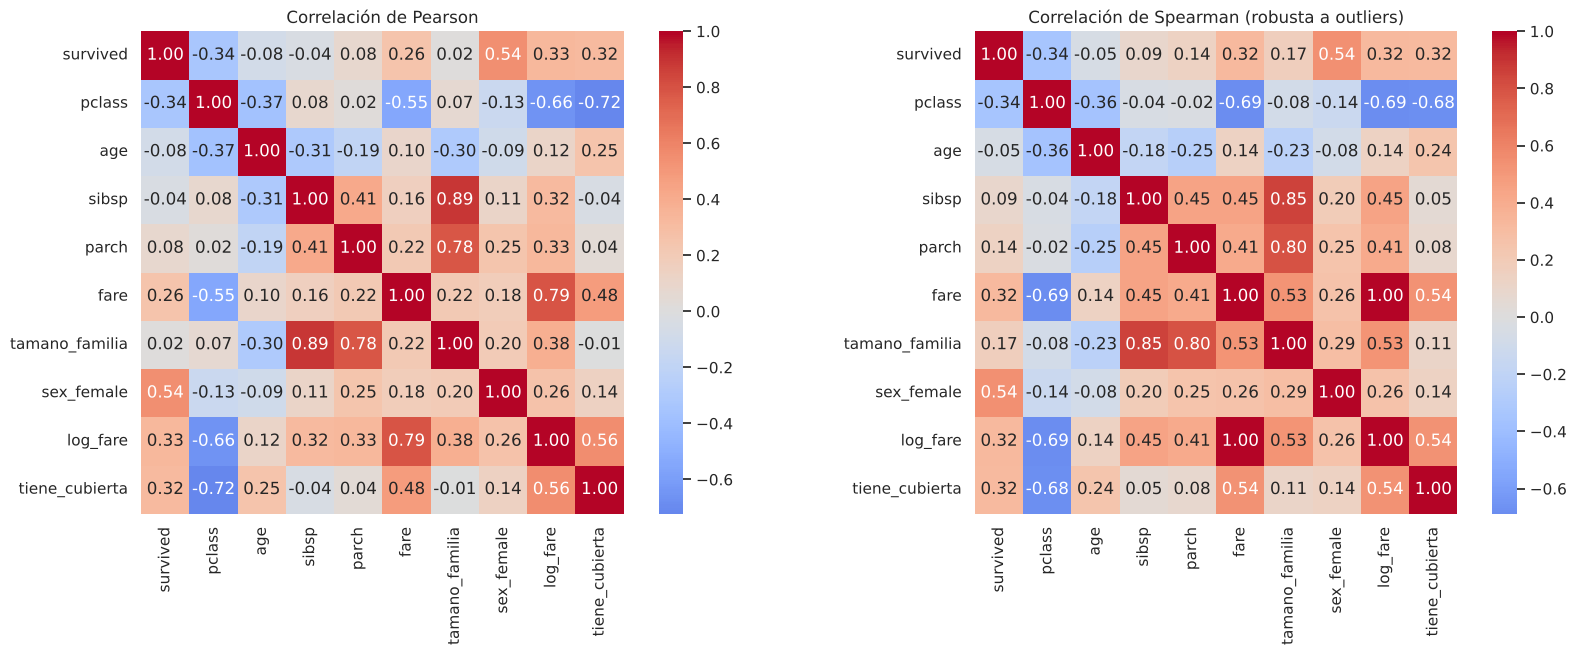

In [24]:
df_corr = df[["survived", "pclass", "age", "sibsp", "parch", "fare", "tamano_familia"]].copy()
df_corr["sex_female"] = (df["sex"] == "female").astype(int)
df_corr["log_fare"] = np.log1p(df["fare"])
df_corr["tiene_cubierta"] = df["deck"].notna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
sns.heatmap(df_corr.corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], square=True)
axes[0].set_title("Correlación de Pearson")
sns.heatmap(df_corr.corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], square=True)
axes[1].set_title("Correlación de Spearman (robusta a outliers)")
guardar("02_heatmap_correlaciones.png")

In [25]:
df_corr.corr()["survived"].drop("survived").sort_values(key=abs, ascending=False).round(3)

sex_female        0.543
pclass           -0.338
log_fare          0.330
tiene_cubierta    0.320
fare              0.257
parch             0.082
age              -0.077
sibsp            -0.035
tamano_familia    0.017
Name: survived, dtype: float64

**Interpretación:**
- La variable más asociada con sobrevivir es el **sexo femenino** (r ≈ 0.54), seguida de la **clase** (r ≈ −0.34: a mayor número de clase, menor supervivencia) y de **`tiene_cubierta`** (r ≈ 0.32), lo que confirma que el faltante de `deck` es informativo.
- **`pclass` y `fare` están fuertemente correlacionadas** de forma negativa (≈ −0.55 en Pearson, ≈ −0.69 en Spearman). Esto indica redundancia parcial, lo que **justifica aplicar PCA** en la siguiente fase.
- `sibsp`, `parch` y `tamano_familia` están muy correlacionadas entre sí (multicolinealidad).
- La edad tiene correlación lineal muy baja con la supervivencia (≈ −0.08), pero ya vimos que su efecto **no es lineal** (los niños).

### 6.4 Pairplot (vista multivariada)

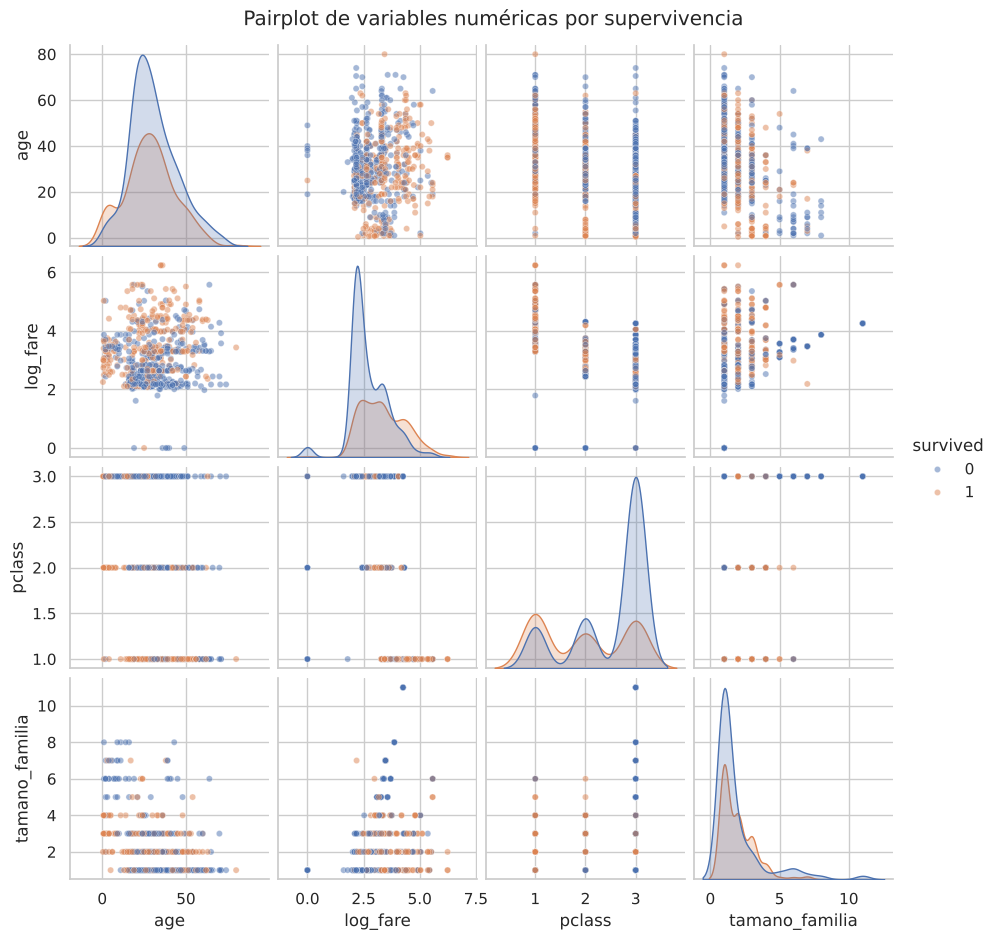

In [26]:
g = sns.pairplot(df[["survived", "age", "fare", "pclass", "tamano_familia"]].assign(fare=np.log1p(df.fare)).rename(columns={"fare": "log_fare"}),
                 hue="survived", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20}, height=2.3)
g.figure.suptitle("Pairplot de variables numéricas por supervivencia", y=1.02)
plt.savefig(FIG / "02_pairplot.png", dpi=110, bbox_inches="tight"); plt.show()

## 7. Hipótesis y verificación estadística

A partir de los patrones anteriores se plantean cinco hipótesis. Se usa un nivel de significancia α = 0.05.

| # | Hipótesis | Prueba |
|---|-----------|--------|
| H1 | La supervivencia depende del **sexo** | Chi-cuadrado de independencia |
| H2 | La supervivencia depende de la **clase** del pasajero | Chi-cuadrado de independencia |
| H3 | Los sobrevivientes pagaron **tarifas más altas** | Mann-Whitney U (no paramétrica, porque `fare` no es normal) |
| H4 | Los **niños (≤ 12 años)** tuvieron mayor probabilidad de sobrevivir que los adultos | Chi-cuadrado de independencia |
| H5 | El **tamaño de la familia** se asocia con la supervivencia (no linealmente) | Chi-cuadrado sobre categorías: solo / 2-4 / 5+ |

In [27]:
def chi2_test(a, b):
    tabla = pd.crosstab(a, b)
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    n = tabla.values.sum(); k = min(tabla.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * k))
    return chi2, p, v_cramer

resultados = []
chi2, p, v = chi2_test(df.sex, df.survived); resultados.append(["H1 sexo", "Chi²", chi2, p, f"V de Cramér={v:.2f}"])
chi2, p, v = chi2_test(df.pclass, df.survived); resultados.append(["H2 clase", "Chi²", chi2, p, f"V de Cramér={v:.2f}"])

u, p = stats.mannwhitneyu(df.loc[df.survived == 1, "fare"], df.loc[df.survived == 0, "fare"], alternative="greater")
med1, med0 = df.loc[df.survived == 1, "fare"].median(), df.loc[df.survived == 0, "fare"].median()
resultados.append(["H3 tarifa", "Mann-Whitney U", u, p, f"mediana {med1:.1f} vs {med0:.1f}"])

edad_ok = df.dropna(subset=["age"])
nino = np.where(edad_ok.age <= 12, "niño", "adulto/adolescente")
chi2, p, v = chi2_test(nino, edad_ok.survived)
tasas = edad_ok.groupby(nino)["survived"].mean()
resultados.append(["H4 niños", "Chi²", chi2, p, f"tasa niños={tasas['niño']:.2f} vs resto={tasas['adulto/adolescente']:.2f}"])

fam = pd.cut(df.tamano_familia, bins=[0, 1, 4, 11], labels=["solo", "2-4", "5+"])
chi2, p, v = chi2_test(fam, df.survived)
resultados.append(["H5 familia", "Chi²", chi2, p, f"V de Cramér={v:.2f}; tasas: " + ", ".join(f"{k}={x:.2f}" for k, x in df.groupby(fam, observed=True).survived.mean().items())])

res = pd.DataFrame(resultados, columns=["hipótesis", "prueba", "estadístico", "p_valor", "efecto"])
res["¿Se rechaza H0 (α=0.05)?"] = np.where(res.p_valor < 0.05, "Sí → hay asociación", "No")
res["p_valor"] = res["p_valor"].apply(lambda x: f"{x:.2e}")
res["estadístico"] = res["estadístico"].round(2)
res

,hipótesis,prueba,estadístico,p_valor,efecto,¿Se rechaza H0 (α=0.05)?
0,H1 sexo,Chi²,260.72,1.20e-58,V de Cramér=0.54,Sí → hay asociación
1,H2 clase,Chi²,102.89,4.55e-23,V de Cramér=0.34,Sí → hay asociación
2,H3 tarifa,Mann-Whitney U,129951.50,2.28e-22,mediana 26.0 vs 10.5,Sí → hay asociación
3,H4 niños,Chi²,8.76,3.08e-03,tasa niños=0.58 vs resto=0.39,Sí → hay asociación
4,H5 familia,Chi²,74.54,6.52e-17,"V de Cramér=0.29; tasas: solo=0.30, 2-4=0.58, ...",Sí → hay asociación


**Conclusiones de las pruebas:** las cinco hipótesis se respaldan estadísticamente (p < 0.05).
- **H1 (sexo)** tiene el efecto más fuerte (V de Cramér ≈ 0.54): el protocolo "mujeres y niños primero" se refleja claramente en los datos.
- **H2 (clase)** tiene un efecto moderado (V ≈ 0.34): la posición social influyó en la supervivencia.
- **H3 (tarifa):** los sobrevivientes pagaron una mediana de tarifa casi 2.5 veces mayor.
- **H4 (niños):** los niños sobrevivieron más que el resto, aunque el efecto es menor que el del sexo.
- **H5 (familia):** confirma la relación no lineal: las familias medianas sobrevivieron más que quienes viajaban solos o en familias grandes.

> Nota: asociación no implica causalidad. Por ejemplo, el efecto de la tarifa está confundido con la clase.

## 8. Insights principales

**Patrones relevantes encontrados**
1. **El sexo es el factor más determinante:** las mujeres sobrevivieron ≈ 74 % frente a ≈ 19 % de los hombres.
2. **La clase social marcó la diferencia:** la supervivencia cae de ≈ 63 % en 1.ª clase a ≈ 47 % en 2.ª y ≈ 24 % en 3.ª.
3. **Sexo y clase interactúan:** las mujeres de 1.ª y 2.ª clase sobrevivieron más del 90 %, pero en 3.ª clase solo el 50 %; los hombres de 2.ª y 3.ª clase, menos del 16 %.
4. **Los niños menores de 12 años sobrevivieron más** (≈ 58 %), mientras que en los adultos la edad casi no influye.
5. **Viajar en familia mediana (2–4 personas) aumentó la supervivencia** (≈ 58 %); viajar solo (≈ 30 %) o en familias de 5 o más (≈ 16 %) la redujo (relación no lineal).
6. **Pagar más se asocia a sobrevivir**, pero esto está explicado en gran parte por la clase (correlación `pclass`–`fare` ≈ −0.55 a −0.69).
7. **Tener la cubierta registrada se asocia a mayor supervivencia** (≈ 67 % vs ≈ 30 %): el dato faltante es informativo por sí mismo.
8. **El puerto de Cherbourg tiene mayor supervivencia** porque la mitad de sus pasajeros eran de 1.ª clase (efecto de composición, no del puerto).

**Problemas de calidad detectados**
- `deck` con ≈ 77 % de faltantes (no aleatorio) → indicador binario.
- `age` con ≈ 20 % de faltantes, más frecuentes en 3.ª clase → imputación por mediana agrupada + indicador.
- `embarked` con 2 faltantes → moda.
- Cinco columnas redundantes (`alive`, `class`, `embark_town`, `alone`, `adult_male`); `alive` causaría **fuga de información** si se usara para modelar.
- `fare` fuertemente sesgada con outliers legítimos → transformación logarítmica.
- Filas duplicadas que corresponden a pasajeros distintos con perfil idéntico (no se eliminan).
- Clase objetivo moderadamente desbalanceada (38 % / 62 %).

**Líneas de análisis para fases posteriores**
- Modelos de clasificación (regresión logística, árboles de decisión, random forest) para predecir `survived`, usando validación estratificada.
- Ingeniería de variables: `tamano_familia` en categorías, interacción `sexo × clase`, grupos de edad.
- Comparar el rendimiento con y sin las variables imputadas para medir el impacto del tratamiento de faltantes.

➡️ Siguiente paso: `03_preprocesamiento_pca.ipynb`.